# 信贷风险评估

### 1. 项目主旨

本项目的目的是构建一个信贷风险评估模型，用来预测借款人在未来两年内是否可能发生严重逾期。数据集中的目标变量是 `SeriousDlqin2yrs`，其中 $0$ 表示正常客户，$1$ 表示未来两年内出现严重逾期的高风险客户。在实际信贷业务中，金融机构在放贷前需要判断申请人的违约风险。如果一个高风险客户被错误批准贷款，机构可能面临坏账损失；但如果过于保守地拒绝正常客户，也会损失潜在业务机会。因此，本项目希望通过借款人的信用行为、收入、负债、历史逾期记录等信息，建立一个模型来辅助识别高风险客户。这个项目解决的核心问题是：如何从大量正常客户中识别出少数潜在坏客户，并为贷款审批、风险筛查和人工复核提供数据支持。

### 2. 导入工具包

代码一开始导入了项目所需的 **Python** 库。**Pandas** 和 **Numpy** 主要用于数据读取、数据清洗和数值计算；**Matplotlib** 和 **Seaborn** 用于可视化分析；**Scikit-learn** 用于数据划分、标准化、模型训练和模型评估；**imblearn** 中的 **SMOTE** 和 **Pipeline** 用于处理样本不平衡问题。这一部分的作用是搭建完整的数据分析和机器学习建模环境，为后续的数据处理、可视化、模型训练和评估做准备。

In [56]:
# 导入常用包
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

### 3. 读取数据与初步探索

项目使用 `pd.read_csv()` 读取 `credit.csv` 文件，并通过 `df.head()`、`df.shape` 和 `df.info()` 查看数据的基本情况。初始数据共有$150,000$条记录和$12$个字段。每一行代表一个借款人，每个字段记录了该借款人的信用行为或财务特征。例如，`RevolvingUtilizationOfUnsecuredLines` 表示信用额度使用率，**age** 表示年龄，`DebtRatio` 表示负债率，`MonthlyIncome` 表示月收入，几个 `past-due` 变量表示不同程度的历史逾期次数。这一阶段的主要目的是了解数据规模、字段类型、是否存在缺失值，以及目标变量是什么。通过初步查看可以发现，这个数据集适合做一个二分类问题，即预测客户是否会严重逾期。

In [57]:
# 读取数据文件
df = pd.read_csv('credit.csv')
df.head(5)



,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [58]:
# 查看数据维度和描述性统计
print("数据维度：", df.shape)
print(df.head())
print(df.info())


数据维度： (150000, 12)
   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13

### 4. 字段、缺失值和目标变量分布检查

在正式清洗数据之前，本项目先检查了各字段的缺失比例和目标变量的类别分布。结果显示，主要存在缺失值的变量是 `MonthlyIncome` 和 `NumberOfDependents`。其中，月收入的缺失比例相对较高，而家庭赡养人数的缺失比例较低。由于这两个变量都可能和客户的还款能力有关，所以后续不能简单地直接删除所有缺失记录，而需要进行更合理的处理。
同时，目标变量的分布显示，正常客户占绝大多数，严重逾期客户只占大约 6% 到 7%。这说明该数据集存在明显的类别不平衡问题。也就是说，如果模型简单地把大部分客户都预测为正常客户，也可能得到较高的accuracy，但这并不代表模型真的能识别坏客户。因此，后续模型评估不能只看accuracy，还需要重点关注坏客户类别的precision、recall、F1-score 和 PR-AUC。

In [59]:
#查看字段和缺失值
print("列名：")
print(df.columns)

print("\n缺失值比例：")
print((df.isnull().mean() * 100).round(2))

print("\n目标变量分布：")
print(df["SeriousDlqin2yrs"].value_counts())
print(df["SeriousDlqin2yrs"].value_counts(normalize=True).round(4))

列名：
Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

缺失值比例：
Unnamed: 0                               0.00
SeriousDlqin2yrs                         0.00
RevolvingUtilizationOfUnsecuredLines     0.00
age                                      0.00
NumberOfTime30-59DaysPastDueNotWorse     0.00
DebtRatio                                0.00
MonthlyIncome                           19.82
NumberOfOpenCreditLinesAndLoans          0.00
NumberOfTimes90DaysLate                  0.00
NumberRealEstateLoansOrLines             0.00
NumberOfTime60-89DaysPastDueNotWorse     0.00
NumberOfDependents                       2.62
dtype: float64

目标变量分布：
SeriousDlqin2yrs
0    139974
1     10026

### 5. 数据清洗

数据清洗的目的是去除明显无意义或异常的记录，提高后续建模的数据质量。首先，代码删除了 `Unnamed: 0` 这一列。它只是原始数据中的编号列，不包含实际业务信息，如果放入模型反而可能引入噪声。然后，代码删除了重复记录，避免模型重复学习完全相同的样本。接着，项目处理了明显异常值，例如删除 `age = 0` 的记录，因为借款人年龄为 $0$ 在实际业务中不合理。此外，几个历史逾期变量中也存在异常大的取值，因此代码对这些极端逾期次数进行了过滤。这类异常值很可能来自编码或录入问题，如果直接保留，可能会影响模型对正常数据规律的学习。经过清洗后，数据仍然保留了大部分样本，说明删除的主要是少量明显异常记录。这一步为后续 EDA 和模型训练提供了更可靠的数据基础。

In [60]:
#基础数据清洗

# 删除导入CSV后自动生成的无效索引列
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
    
# 删除重复行
df = df.drop_duplicates()

# 删除 age = 0 的异常值
df = df[df["age"] > 0]

# 处理逾期次数中的异常值
late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in late_cols:
    df = df[df[col] < 90]

print("清洗后数据维度：", df.shape)
print(df.head())

清洗后数据维度： (149165, 11)
   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0                 1                              0.766127   45   
1                 0                              0.957151   40   
2                 0                              0.658180   38   
3                 0                              0.233810   30   
4                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                        0   
1                                4      

### 6. 添加缺失值标记变量

在处理缺失值之前，代码先创建了两个缺失值标记变量：`MonthlyIncome_missing`, `NumberOfDependents_missing`。这两个变量分别表示月收入和家庭赡养人数是否原本缺失。这样做的原因是，缺失本身可能包含风险信息。比如，一个客户没有填写收入，可能反映出其财务信息不完整，也可能和信用风险有关。如果只是简单用中位数填补，模型就无法知道这个值原本是缺失的。加入缺失值标记后，模型既能使用填补后的数值，也能利用“该字段是否缺失”这一信息。因此，这一步不是简单地处理缺失值，而是尽量保留缺失信息中可能具有的业务含义。

In [61]:
#添加缺失值标记变量

# 收入缺失本身可能也是风险信号，所以加一个 indicator
df["MonthlyIncome_missing"] = df["MonthlyIncome"].isnull().astype(int)
df["NumberOfDependents_missing"] = df["NumberOfDependents"].isnull().astype(int)

print(df[["MonthlyIncome_missing", "NumberOfDependents_missing"]].mean())

MonthlyIncome_missing         0.195361
NumberOfDependents_missing    0.025549
dtype: float64


### 7. 探索性数据分析 (EDA)

在完成基础清洗和缺失值标记变量构造后，项目进行了探索性数据分析。EDA 放在train/test split之前，主要目的是在建模前了解整体数据结构、变量分布和潜在风险信号。由于EDA只是用于观察数据特征，并不参与模型训练，因此基于清洗后的整体数据进行分析是合理的。<br>

1. 目标变量分布：进一步确认了数据存在明显的类别不平衡。正常客户数量远高于严重逾期客户数量，这说明后续模型不能只依赖accuracy，而要更加关注坏客户类别的recall、precision、F1-score 和PR-AUC。这个发现也解释了为什么后续需要使用SMOTE来帮助模型学习少数类样本。<br>

2. 年龄分布：展示了借款人的年龄结构。大部分客户集中在成年人和中年群体，极端年轻或极端年长的客户相对较少。年龄可能与收入稳定性、信用历史长度和还款能力有关，因此它是一个有业务意义的信贷风险特征。<br>

3. 月收入分布：有明显的右偏特征。大部分客户收入集中在较低到中等区间，少数客户收入非常高。为了避免极端高收入值影响图像展示，代码使用$99%$分位数限制横轴范围，让主要分布更加清晰。收入可以反映客户的还款能力，因此它很可能与违约风险有关。<br>

4. 逾期次数箱线图：项目还通过箱线图观察了三个历史逾期变量，包括$30–59$天逾期、$60–89$天逾期和$90$天以上逾期次数。结果显示，大多数客户历史逾期次数较少，但仍有部分客户存在较高逾期记录。历史逾期行为通常是判断未来违约风险的重要信号，因此这些变量很可能是模型中的重要风险特征。<br>

5. 相关性热力图：用于观察变量之间的线性关系。它可以帮助我们初步判断哪些变量之间可能存在较强相关性，以及哪些变量可能和目标变量有关。不过，相关性并不代表因果关系，所以热力图更多是作为探索性参考，最终还需要结合模型结果进行解释。<br>

EDA 表明该数据集是一个典型的不平衡信贷风险数据集，并且年龄、月收入、历史逾期记录等变量都可能与未来严重逾期风险有关。因此，下一步需要将数据划分为特征矩阵$X$和目标变量$y$，并进一步划分训练集和测试集，为后续缺失值填补、SMOTE处理和机器学习建模做准备。


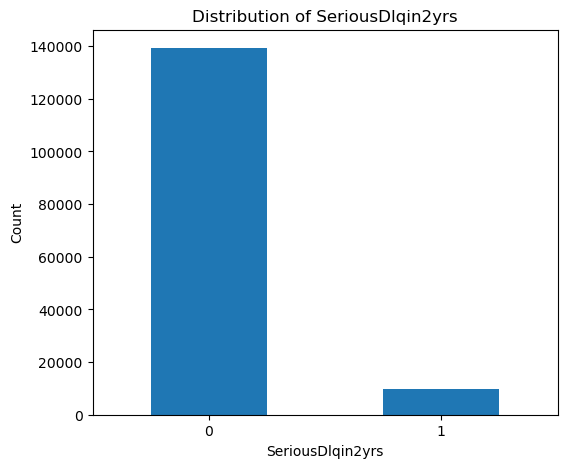

SeriousDlqin2yrs
0    0.9338
1    0.0662
Name: proportion, dtype: float64


In [62]:
#EDA：目标变量分布
plt.figure(figsize=(6, 5))

df["SeriousDlqin2yrs"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of SeriousDlqin2yrs")
plt.xlabel("SeriousDlqin2yrs")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print(df["SeriousDlqin2yrs"].value_counts(normalize=True).round(4))

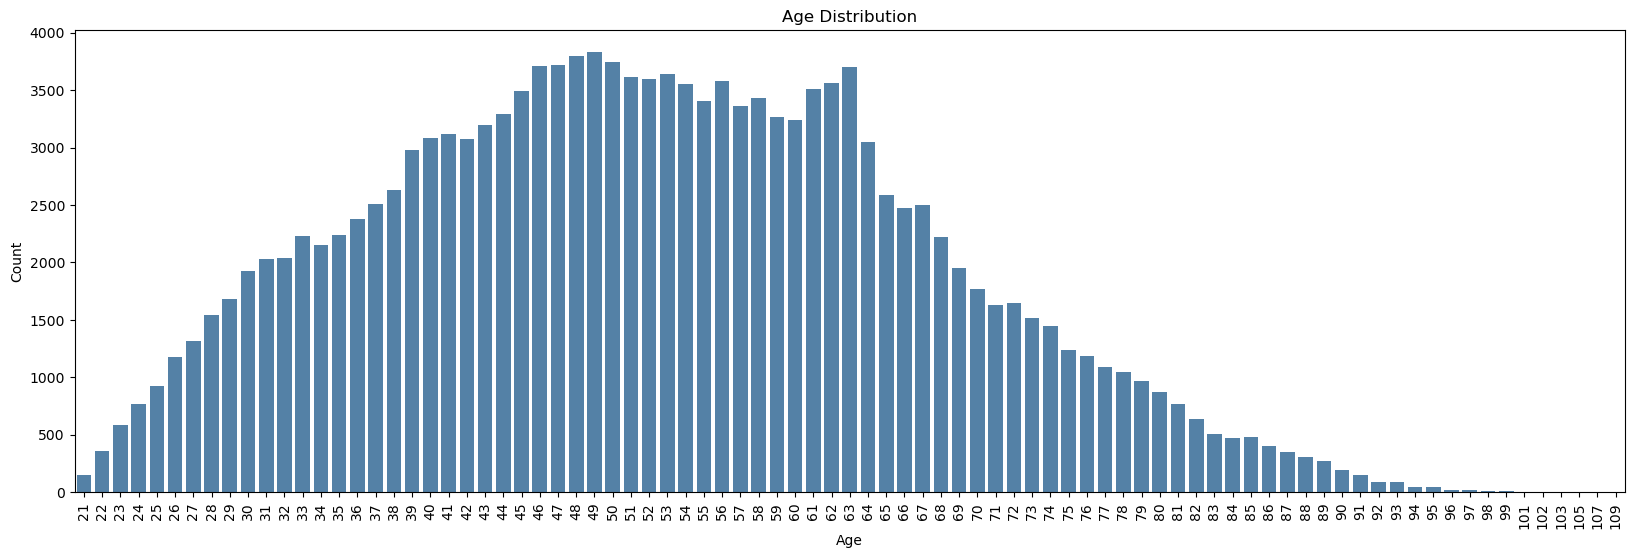

In [63]:
#EDA：年龄分布
plt.figure(figsize=(20, 6))

sns.countplot(
    x="age",
    data=df,
    color="steelblue"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

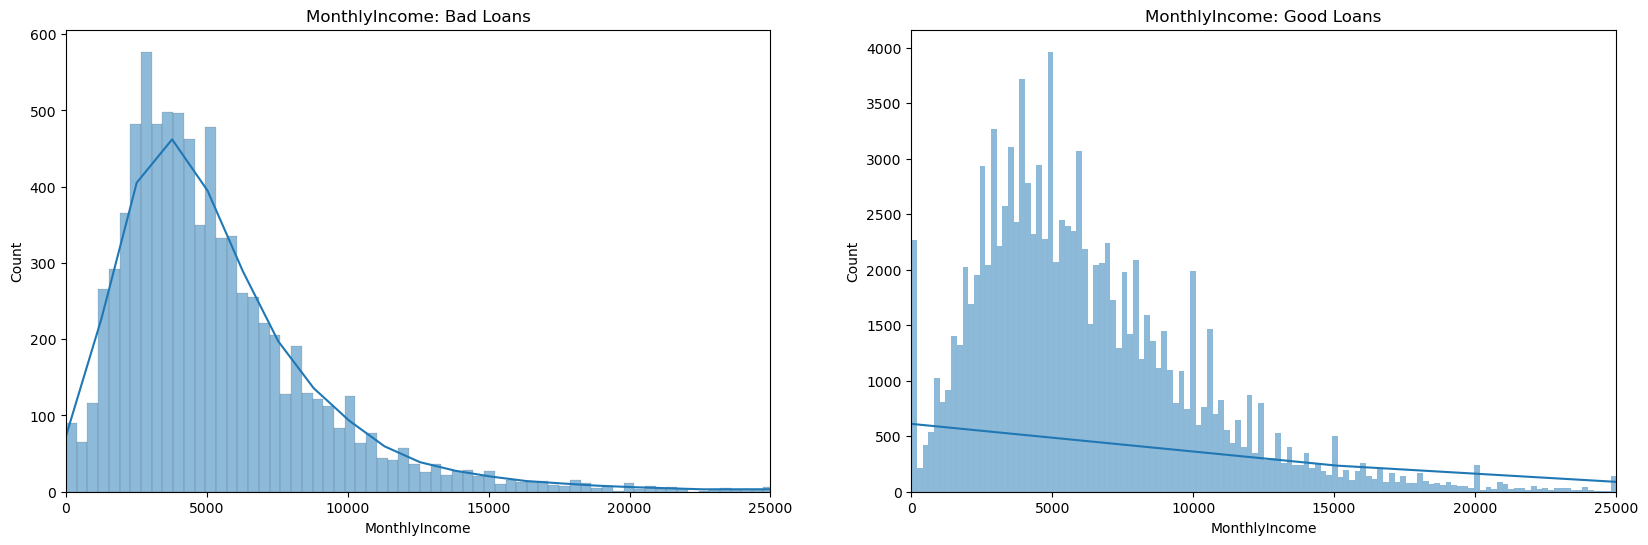

In [64]:
#EDA：收入分布
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

sns.histplot(
    data=df[df["SeriousDlqin2yrs"] == 1],
    x="MonthlyIncome",
    kde=True,
    ax=ax[0]
)

ax[0].set_title("MonthlyIncome: Bad Loans")
ax[0].set_xlim(0, df["MonthlyIncome"].quantile(0.99))

sns.histplot(
    data=df[df["SeriousDlqin2yrs"] == 0],
    x="MonthlyIncome",
    kde=True,
    ax=ax[1]
)

ax[1].set_title("MonthlyIncome: Good Loans")
ax[1].set_xlim(0, df["MonthlyIncome"].quantile(0.99))

plt.show()

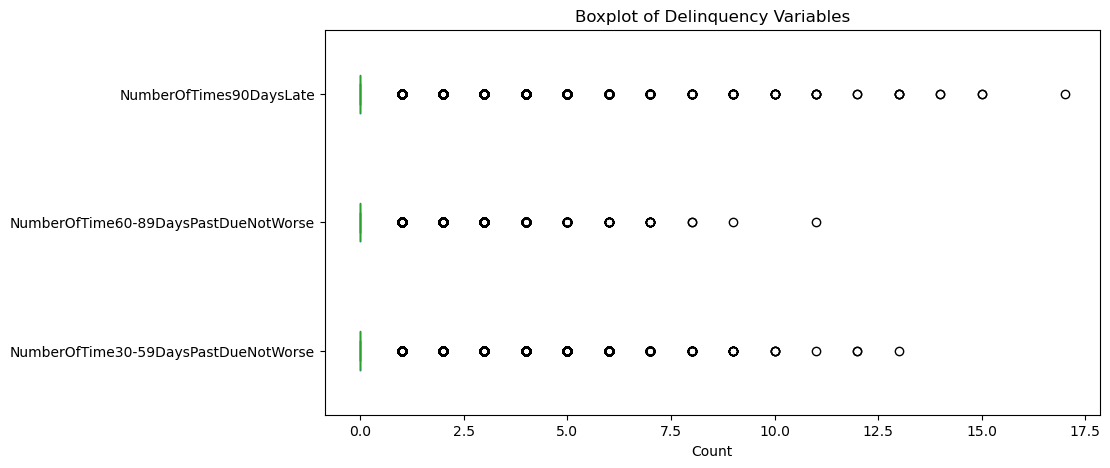

In [65]:
#EDA：逾期次数箱线图
ax = df[late_cols].plot.box(
    vert=False,
    figsize=(10, 5)
)

ax.set_title("Boxplot of Delinquency Variables")
ax.set_xlabel("Count")
plt.show()

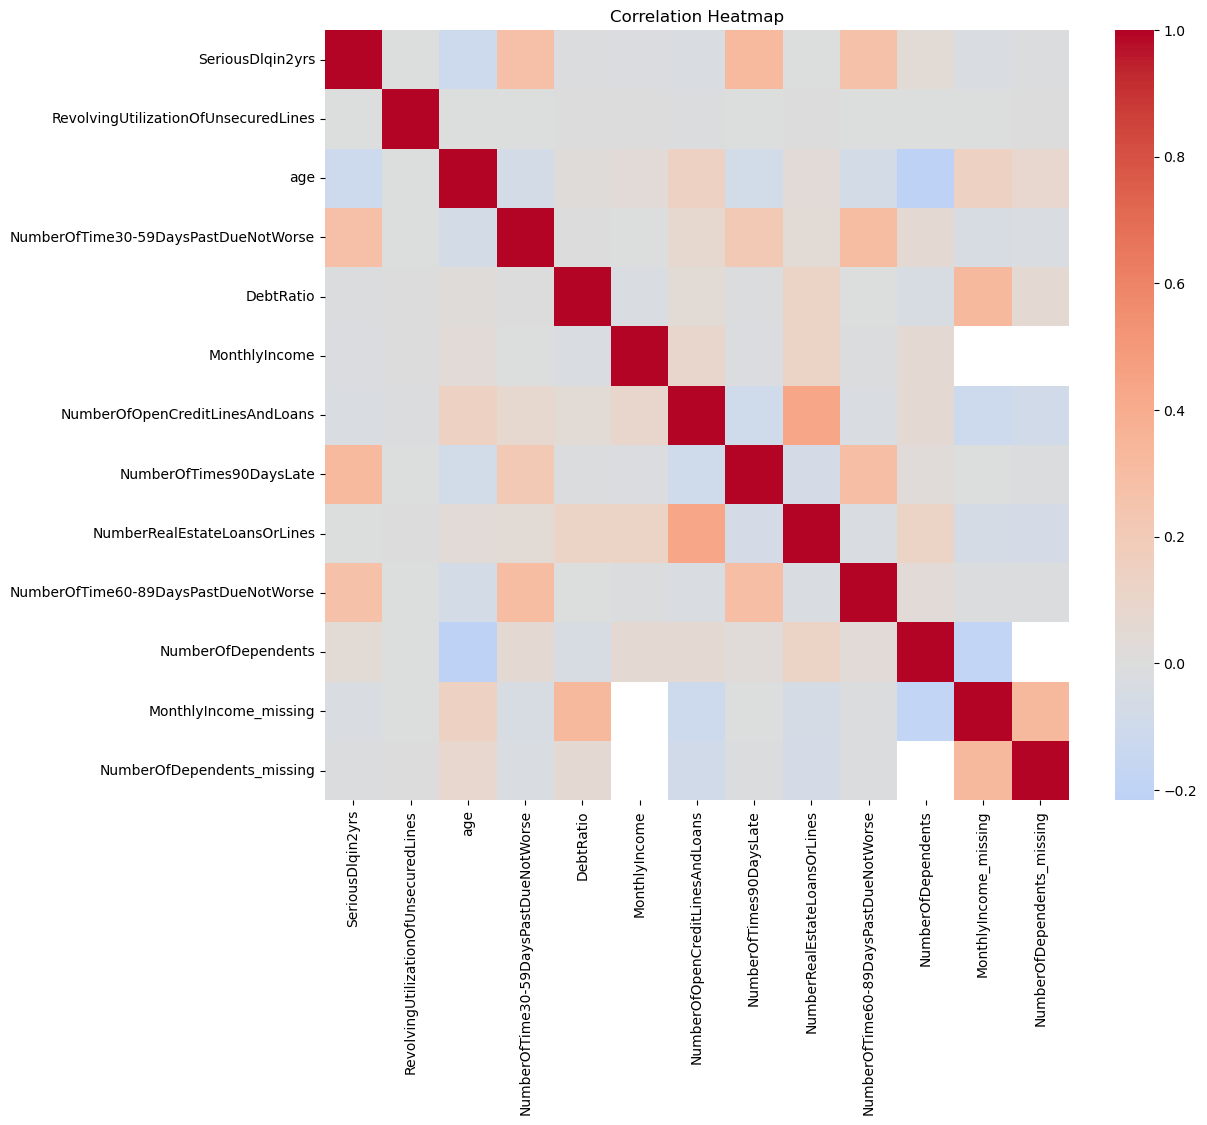

In [66]:
#EDA：相关性热力图
plt.figure(figsize=(12, 10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

### 8. 划分特征和目标变量&训练集/测试集划分

- 在EDA之后，代码将数据划分为特征矩阵 $X$ 和目标变量 $y$。$X$ 包含所有用于预测的变量，包括信用额度使用率、年龄、历史逾期次数、负债率、月收入、开放信贷数量、房贷数量、家庭赡养人数，以及前面创建的缺失值标记变量。$y$ 是目标变量 `SeriousDlqin2yrs`，表示客户是否在未来两年内发生严重逾期。这一步的作用是为后续机器学习模型训练准备输入特征和预测目标。

- 代码使用 train_test_split() 将数据划分为训练集和测试集，其中测试集比例为 30%。这里使用了 stratify=y，保证划分后训练集和测试集中的违约比例与原始数据一致，避免随机划分导致测试集中违约样本过少。

- 先划分训练集和测试集，再进行缺失值填补和 SMOTE。这样可以避免数据泄露。测试集应该模拟真实未来数据，所以不能参与训练过程中的数据处理。

In [67]:
#划分 X 和 y
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

print("特征维度：", X.shape)
print("标签维度：", y.shape)

print("\n违约比例：")
print(y.value_counts(normalize=True).round(4))

特征维度： (149165, 12)
标签维度： (149165,)

违约比例：
SeriousDlqin2yrs
0    0.9338
1    0.0662
Name: proportion, dtype: float64


In [68]:
#先划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)

print("\n训练集目标变量比例：")
print(y_train.value_counts(normalize=True).round(4))

print("\n测试集目标变量比例：")
print(y_test.value_counts(normalize=True).round(4))

训练集： (104415, 12)
测试集： (44750, 12)

训练集目标变量比例：
SeriousDlqin2yrs
0    0.9338
1    0.0662
Name: proportion, dtype: float64

测试集目标变量比例：
SeriousDlqin2yrs
0    0.9338
1    0.0662
Name: proportion, dtype: float64


### 9. 缺失值填补

- 在划分训练集和测试集之后，代码使用训练集中的中位数来填补 `MonthlyIncome` 和 `NumberOfDependents` 的缺失值。这里使用训练集的中位数，而不是整个数据的，是为了避免数据泄露。如果使用了测试集的信息来填补训练过程中的缺失值，模型评估结果可能会偏乐观。

- 选择中位数而不是均值，是因为收入变量存在明显偏态和极端值。中位数对极端值不敏感，更稳健。填补完成后，训练集和测试集都不再存在缺失值，可以进入模型训练阶段。

In [69]:
#缺失值填补
monthly_income_median = X_train["MonthlyIncome"].median()
dependents_median = X_train["NumberOfDependents"].median()

X_train["MonthlyIncome"] = X_train["MonthlyIncome"].fillna(monthly_income_median)
X_test["MonthlyIncome"] = X_test["MonthlyIncome"].fillna(monthly_income_median)

X_train["NumberOfDependents"] = X_train["NumberOfDependents"].fillna(dependents_median)
X_test["NumberOfDependents"] = X_test["NumberOfDependents"].fillna(dependents_median)

print("训练集缺失值：")
print(X_train.isnull().sum())

print("\n测试集缺失值：")
print(X_test.isnull().sum())

训练集缺失值：
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_missing                   0
NumberOfDependents_missing              0
dtype: int64

测试集缺失值：
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_missing                   0
Numb

### 10. 定义模型评估函数

项目定义了一个统一的 evaluate_model() 函数，用来评估不同模型的表现。这个函数会输出 classification report、confusion matrix，并计算 accuracy、bad-loan precision、bad-loan recall、bad-loan F1-score、ROC-AUC 和 PR-AUC。这样做的好处是，后面对 Logistic Regression 和 Random Forest 的评估可以使用同一套标准，方便比较模型表现。在这个项目中，最重要的指标不是 accuracy，而是坏客户类别的 precision、recall、F1-score 和 PR-AUC。因为坏客户比例很低，accuracy 容易误导模型表现；而 PR-AUC 和 bad-loan F1-score 更能反映模型对少数类坏客户的识别能力。

In [70]:
#定义模型评估函数
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_BadLoan": precision_score(y_test, y_pred, pos_label=1),
        "Recall_BadLoan": recall_score(y_test, y_pred, pos_label=1),
        "F1_BadLoan": f1_score(y_test, y_pred, pos_label=1)
    }
    
    if y_proba is not None:
        result["ROC_AUC"] = roc_auc_score(y_test, y_proba)
        result["PR_AUC"] = average_precision_score(y_test, y_proba)
    
    return result

### 11. Logistic Regression + SMOTE 模型

- 项目首先训练的是Logistic Regression + SMOTE模型。代码使用`ImbPipeline`将`StandardScaler`、`SMOTE` 和`LogisticRegression`串联在一起。
- `StandardScaler`用于标准化特征。Logistic Regression对变量尺度比较敏感，如果变量量纲差异很大，可能会影响模型训练。标准化后，不同变量的系数也更容易比较。
- `SMOTE`用于处理类别不平衡。它只作用于训练过程，通过合成少数类样本，让模型更好地学习坏客户特征。这里`SMOTE`被放在pipeline中，因此不会影响测试集，避免了数据泄露。
- Logistic Regression 是一个可解释性较强的模型，适合用于信贷风险场景。它不仅可以预测违约概率，还可以通过系数解释每个变量对违约风险的影响方向。

In [71]:
logit_model = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logit_model.fit(X_train, y_train)

logit_result = evaluate_model(
    logit_model,
    X_test,
    y_test,
    "Logistic Regression + SMOTE"
)

Logistic Regression + SMOTE

Classification Report:
              precision    recall  f1-score   support

           0     0.9705    0.8630    0.9136     41788
           1     0.2457    0.6296    0.3535      2962

    accuracy                         0.8476     44750
   macro avg     0.6081    0.7463    0.6335     44750
weighted avg     0.9225    0.8476    0.8765     44750

Confusion Matrix:
[[36063  5725]
 [ 1097  1865]]


### 12. Logistic Regression 系数解释

- 在Logistic Regression模型训练完成后，项目提取了模型的标准化系数，并将它们整理成表格和图像。
- Logistic Regression的系数主要有两个含义。第一，系数的正负表示影响方向：正系数说明变量越大，模型越倾向于预测客户发生严重逾期；负系数说明变量越大，模型越倾向于预测客户不发生严重逾期。第二，系数绝对值表示影响强度。由于模型训练前使用了`StandardScaler`，不同变量的系数可以进行相对比较。
- 图中红色代表正系数，也就是提高违约风险的变量；蓝色代表负系数，也就是降低违约风险的变量。结果显示，历史逾期变量是重要的风险驱动因素。例如，$90$天以上逾期次数、$30 – 59$天逾期次数和$60 – 89$天逾期次数都是正系数，说明历史逾期次数越多，客户未来发生严重逾期的风险越高。
- 相反，`MonthlyIncome`和`age`是负系数，说明月收入越高、年龄越大，模型预测的违约风险越低。这个结果符合信贷风险逻辑，因为较高收入通常代表更强的还款能力，而年龄较大的客户可能拥有更稳定的财务状况和更长的信用历史。

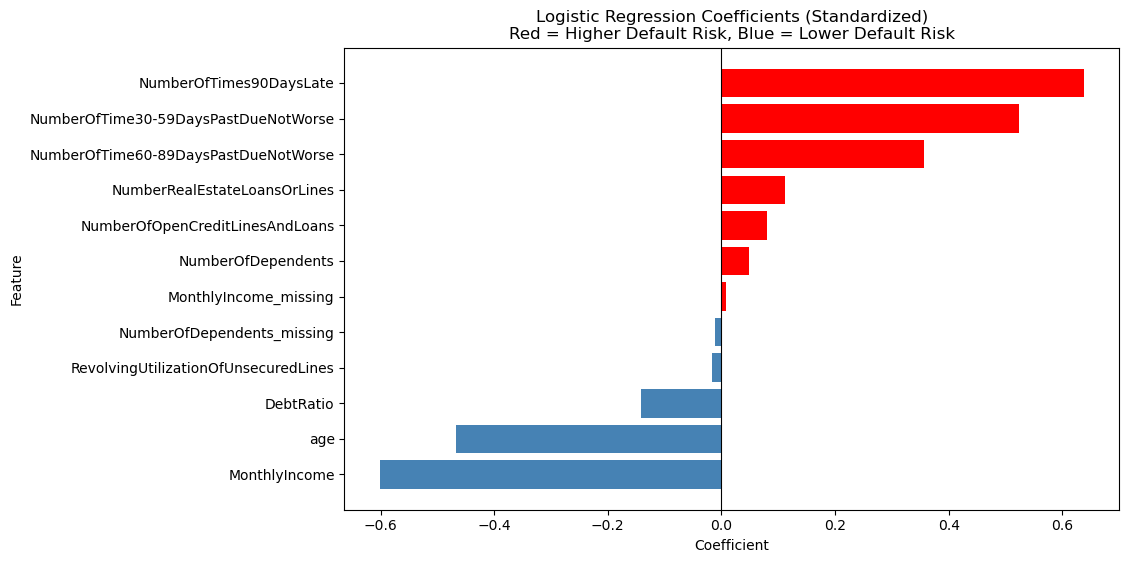

                                 Feature  Coefficient  Abs_Coefficient
4                          MonthlyIncome    -0.601624         0.601624
1                                    age    -0.467001         0.467001
3                              DebtRatio    -0.141865         0.141865
0   RevolvingUtilizationOfUnsecuredLines    -0.017385         0.017385
11            NumberOfDependents_missing    -0.011640         0.011640
10                 MonthlyIncome_missing     0.007129         0.007129
9                     NumberOfDependents     0.047731         0.047731
5        NumberOfOpenCreditLinesAndLoans     0.080310         0.080310
7           NumberRealEstateLoansOrLines     0.111163         0.111163
8   NumberOfTime60-89DaysPastDueNotWorse     0.356803         0.356803
2   NumberOfTime30-59DaysPastDueNotWorse     0.522915         0.522915
6                NumberOfTimes90DaysLate     0.638363         0.638363


In [72]:
#Logistic Regression Coefficient Analysis

# 提取 Logistic Regression 的标准化系数
logit_coef = logit_model.named_steps["model"].coef_[0]

# 整理成 DataFrame
logit_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logit_coef,
    "Abs_Coefficient": np.abs(logit_coef)
})

# 按系数从小到大排序：蓝色负系数在上面，红色正系数在下面
logit_importance = logit_importance.sort_values(
    by="Coefficient",
    ascending=True
)

plt.figure(figsize=(10, 6))

colors = [
    "red" if c > 0 else "steelblue"
    for c in logit_importance["Coefficient"]
]

plt.barh(
    logit_importance["Feature"],
    logit_importance["Coefficient"],
    color=colors
)

plt.axvline(x=0, color="black", linewidth=0.8)

plt.title(
    "Logistic Regression Coefficients (Standardized)\n"
    "Red = Higher Default Risk, Blue = Lower Default Risk"
)
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

print(logit_importance)

### 13. Random Forest + SMOTE 模型

- 为了和Logistic Regression进行比较，项目还训练了Random Forest + SMOTE模型。Random Forest是一种树模型集成方法，能够捕捉变量之间更复杂的非线性关系。相比 Logistic Regression，它不依赖线性假设，因此可以作为一个更复杂的模型进行对照。
- 代码同样使用`ImbPipeline`，先通过SMOTE处理训练集中的类别不平衡问题，再训练Random Forest模型。这个模型的作用是观察更复杂的非线性模型是否能在信贷违约预测中带来更好的表现。

In [73]:
#Model 2：Random Forest
rf_model = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_result = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest + SMOTE"
)

Random Forest + SMOTE

Classification Report:
              precision    recall  f1-score   support

           0     0.9708    0.8356    0.8982     41788
           1     0.2178    0.6455    0.3257      2962

    accuracy                         0.8231     44750
   macro avg     0.5943    0.7406    0.6119     44750
weighted avg     0.9210    0.8231    0.8603     44750

Confusion Matrix:
[[34920  6868]
 [ 1050  1912]]


### 14. 模型对比

模型对比部分展示了Logistic Regression + SMOTE 和Random Forest + SMOTE在测试集上的表现。结果显示，Logistic Regression在PR-AUC和坏客户F1-score等关键指标上表现更好，因此项目最终选择Logistic Regression + SMOTE作为最优模型。这个选择是合理的。对于不平衡分类问题，PR-AUC比accuracy更能体现模型对少数类的识别能力；同时，Logistic Regression的可解释性更强，更适合信贷风险这种需要说明判断依据的场景。因此，最终模型不仅要有较好的预测表现，也要能够解释哪些因素会提高或降低客户的违约风险。

In [74]:
#模型对比表
results = pd.DataFrame([logit_result, rf_result])

results = results.sort_values(by="PR_AUC", ascending=False)

print(results)

                         Model  Accuracy  Precision_BadLoan  Recall_BadLoan  \
0  Logistic Regression + SMOTE  0.847553           0.245718        0.629642   
1        Random Forest + SMOTE  0.823061           0.217768        0.645510   

   F1_BadLoan  ROC_AUC    PR_AUC  
0    0.353487  0.81718  0.350925  
1    0.325669  0.82992  0.298063  


In [75]:
if logit_result["PR_AUC"] >= rf_result["PR_AUC"]:
    best_model = logit_model
    best_model_name = "Logistic Regression + SMOTE"
else:
    best_model = rf_model
    best_model_name = "Random Forest + SMOTE"

print("Best model:", best_model_name)

y_proba = best_model.predict_proba(X_test)[:, 1]

Best model: Logistic Regression + SMOTE


### 15. Precision-Recall曲线

在选出最佳模型后，项目绘制了Precision-Recall Curve。PR Curve展示了不同临界值下precision和recall之间的变化关系。对于这个项目来说，PR Curve比ROC Curve更有参考价值，因为坏客户是少数类，PR Curve更关注模型对坏客户的识别效果。PR-AUC越高，说明模型在不同临界值下识别坏客户的整体能力越强。这一部分的作用是从整体上观察模型对少数类客户的识别能力，而不是只依赖某一个固定临界值下的结果。

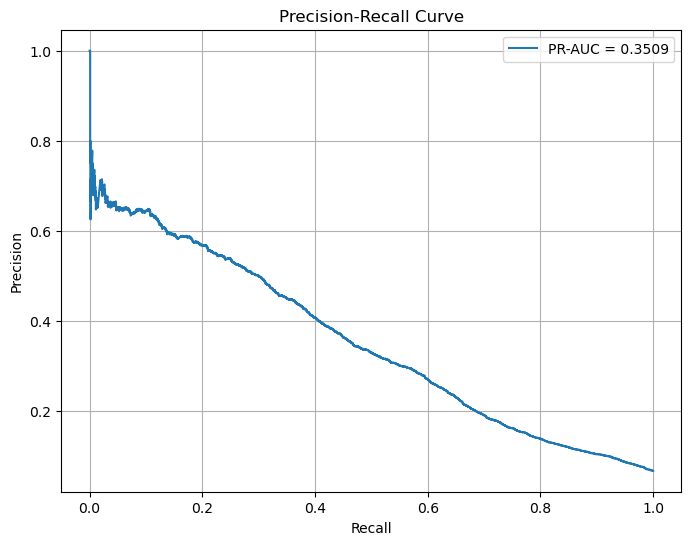

In [76]:
#PR Curve
y_proba = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

### 16. 不同临界值下的表现分析

- 模型输出的是违约概率，但在实际应用中，需要设定一个临界值，把概率转化为“正常客户”或“坏客户”的分类结果。因此，项目测试了不同临界值下的模型表现，并比较每个临界值对应的bad-loan precision、bad-loan recall、F1-score和accuracy。
- 一般来说，临界值越低，模型越容易把客户判定为坏客户，因此recall会提高，但precision和accuracy可能下降，因为更多正常客户也会被误判为高风险。临界值越高，模型越谨慎地判定坏客户，precision和accuracy可能提高，但recall会下降，因为更多真实坏客户会被漏掉。
- 项目最终根据F1_BadLoan自动选择最佳临界值，这样可以让最终分类结果更有数据依据。不过，从业务角度看，临界值并没有绝对最优。如果金融机构更希望尽可能抓住高风险客户，可以选择较低的临界值；如果更希望减少对正常客户的误判，则可以选择较高的临界值。

In [77]:
#不同 threshold 下的表现
threshold_list = np.arange(0.1, 0.51, 0.05).round(2)

threshold_results = []

for threshold in threshold_list:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision_BadLoan": precision_score(y_test, y_pred_threshold, pos_label=1),
        "Recall_BadLoan": recall_score(y_test, y_pred_threshold, pos_label=1),
        "F1_BadLoan": f1_score(y_test, y_pred_threshold, pos_label=1),
        "Accuracy": accuracy_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

   Threshold  Precision_BadLoan  Recall_BadLoan  F1_BadLoan  Accuracy
0       0.10           0.066509        0.997974    0.124707  0.072737
1       0.15           0.069202        0.990209    0.129364  0.117788
2       0.20           0.076201        0.976030    0.141366  0.215218
3       0.25           0.087731        0.944632    0.160551  0.346168
4       0.30           0.103125        0.898042    0.185005  0.476291
5       0.35           0.122695        0.835584    0.213971  0.593654
6       0.40           0.151306        0.770425    0.252937  0.698771
7       0.45           0.190978        0.697502    0.299855  0.784402
8       0.50           0.245718        0.629642    0.353487  0.847553


### 17. Confusion Matrix

在确定临界值后，项目使用该临界值生成最终预测结果，并绘制confusion matrix。Confusion matrix可以把模型预测结果分成四类：
1. 正常客户被正确预测为正常
2. 正常客户被误判为坏客户
3. 坏客户被误判为正常
4. 坏客户被正确识别为坏客户

在信贷风险场景中，坏客户被误判为正常客户，也就是false negative，通常比较危险，因为这意味着模型漏掉了真正的高风险客户。另一方面，正常客户被误判为坏客户，也就是false positive，也会带来问题，因为这可能导致额外审核，甚至影响正常客户的贷款申请。因此，confusion matrix的作用是把模型指标和真实业务后果联系起来，帮助理解模型在实际使用中可能带来的风险和取舍。

Chosen threshold based on highest F1-score for bad loans: 0.5


,Threshold,Precision_BadLoan,Recall_BadLoan,F1_BadLoan,Accuracy
8,0.5,0.245718,0.629642,0.353487,0.847553


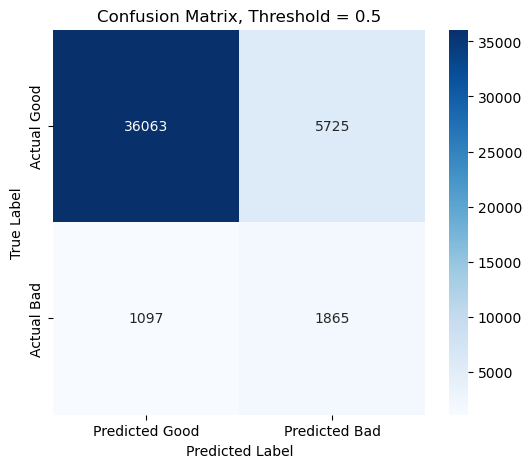

              precision    recall  f1-score   support

           0     0.9705    0.8630    0.9136     41788
           1     0.2457    0.6296    0.3535      2962

    accuracy                         0.8476     44750
   macro avg     0.6081    0.7463    0.6335     44750
weighted avg     0.9225    0.8476    0.8765     44750



In [78]:
#Confusion Matrix 可视化

# 根据 bad-loan F1-score 自动选择最佳 threshold
best_threshold = threshold_df.loc[
    threshold_df["F1_BadLoan"].idxmax(),
    "Threshold"
]

chosen_threshold = best_threshold

print("Chosen threshold based on highest F1-score for bad loans:", chosen_threshold)

display(
    threshold_df[threshold_df["Threshold"] == chosen_threshold]
)

# 用最佳 threshold 生成最终预测结果
y_pred_chosen = (y_proba >= chosen_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_chosen)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Good", "Predicted Bad"],
    yticklabels=["Actual Good", "Actual Bad"]
)

plt.title(f"Confusion Matrix, Threshold = {chosen_threshold}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print(classification_report(y_test, y_pred_chosen, digits=4))

### 18. Random Forest Feature Importance

- 虽然最终模型选择的是Logistic Regression，但项目也展示了Random Forest的特征重要性，作为补充解释。这个图可以帮助观察树模型认为哪些变量对预测结果更重要。
结果显示，信用额度使用率、家庭赡养人数、历史逾期变量、年龄和负债率等变量具有一定重要性。不过，Random Forest的特征重要性是基于impurity reduction计算的，可能会受到变量分布和取值范围影响，因此更适合作为辅助参考，而不是主要结论。
- 本项目主要还是使用Logistic Regression的系数方向来解释违约风险，因为Logistic Regression是最终选择的模型，而且它的系数可以更直接地说明某个变量是提高风险还是降低风险。

                                 Feature  Importance
0   RevolvingUtilizationOfUnsecuredLines    0.406047
9                     NumberOfDependents    0.242503
6                NumberOfTimes90DaysLate    0.080951
2   NumberOfTime30-59DaysPastDueNotWorse    0.072398
1                                    age    0.047125
3                              DebtRatio    0.041625
7           NumberRealEstateLoansOrLines    0.037725
4                          MonthlyIncome    0.027218
5        NumberOfOpenCreditLinesAndLoans    0.019606
8   NumberOfTime60-89DaysPastDueNotWorse    0.018388
10                 MonthlyIncome_missing    0.003736
11            NumberOfDependents_missing    0.002678


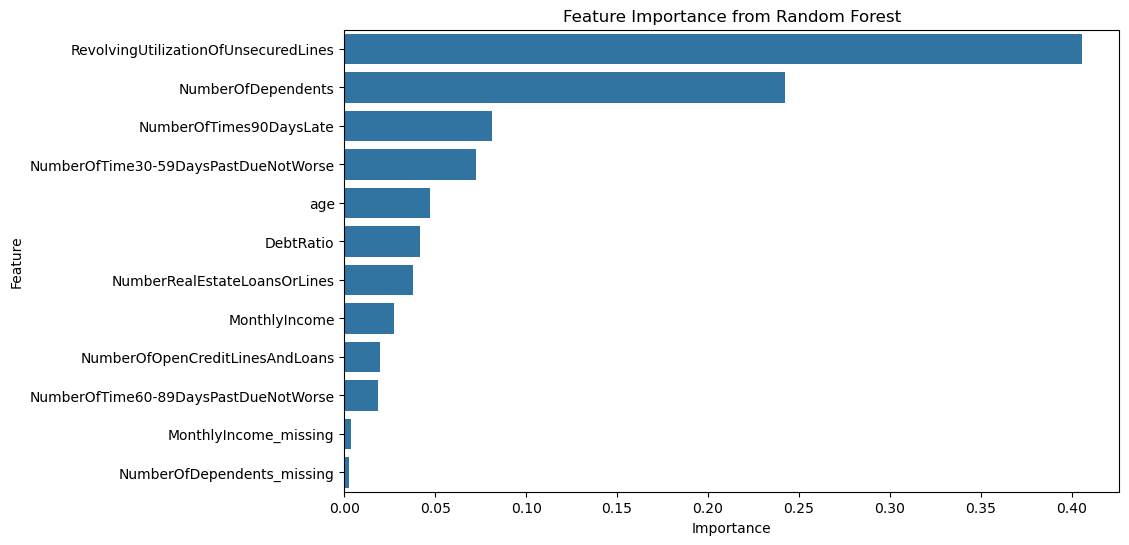

In [79]:
#Random Forest 特征重要性
rf_classifier = rf_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### 19. Conclusion

- 本项目完成了一个完整的信贷风险预测流程，包括数据读取、数据清洗、缺失值处理、探索性数据分析、类别不平衡处理、模型训练、模型对比、临界值调整和模型解释。
- 从结果来看，历史逾期记录是预测未来严重逾期风险的重要因素。尤其是 90 天以上逾期次数、30–59 天逾期次数和 60–89 天逾期次数，这些变量在 Logistic Regression 中均为正系数，说明历史逾期次数越多，客户被预测为坏客户的概率越高。与此同时，月收入和年龄为负系数，说明收入较高和年龄较大的客户通常被模型认为风险较低。
- 在模型选择上，Logistic Regression + SMOTE 根据 PR-AUC 和 bad-loan F1-score 被选为最终模型。虽然 Random Forest 的 ROC-AUC 略高，但 Logistic Regression 在少数类识别指标和可解释性方面更符合本项目目标。
- 总体来说，这个项目解决的是如何利用借款人的信用和财务信息，从高度不平衡的数据中识别潜在高风险客户的问题。最终模型可以作为贷款审批前的风险筛查工具，帮助金融机构提前发现可能违约的客户，降低潜在坏账风险，并辅助后续人工复核和贷款决策。